# Weather vs Energy Usage Prediction

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/energydata_complete.csv')
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

In [6]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [7]:
df.isnull().sum()

,0
date,0
Appliances,0
lights,0
T1,0
RH_1,0
T2,0
RH_2,0
T3,0
RH_3,0
T4,0


In [8]:
# Select only 3 input features
features = ['T_out', 'RH_out', 'Windspeed']

X = df[features]
y = df['Appliances']

In [9]:

print("Mean:\n", X.mean())
print("\nMedian:\n", X.median())
print("\nMode:\n", X.mode().iloc[0])
print("\nVariance:\n", X.var())
print("\nStandard Deviation:\n", X.std())

Mean:
 T_out         7.411665
RH_out       79.750418
Windspeed     4.039752
dtype: float64

Median:
 T_out         6.916667
RH_out       83.666667
Windspeed     3.666667
dtype: float64

Mode:
 T_out         9.8
RH_out       95.0
Windspeed     1.0
Name: 0, dtype: float64

Variance:
 T_out         28.274836
RH_out       222.042410
Windspeed      6.008482
dtype: float64

Standard Deviation:
 T_out         5.317409
RH_out       14.901088
Windspeed     2.451221
dtype: float64


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model training
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [14]:
# Intercept and coefficients
a0 = model.intercept_
a1, a2, a3 = model.coef_

print("Intercept (a0):", a0)
print("Coefficient a1 (T_out):", a1)
print("Coefficient a2 (RH_out):", a2)
print("Coefficient a3 (Windspeed):", a3)

print("\nFinal Regression Equation:")
print(f"Energy = {a0:.2f} + ({a1:.2f} * T_out) + ({a2:.2f} * RH_out) + ({a3:.2f} * Windspeed)")

Intercept (a0): 159.4290775077403
Coefficient a1 (T_out): 0.2349749002658846
Coefficient a2 (RH_out): -0.9207568750042612
Coefficient a3 (Windspeed): 2.5490933732321754

Final Regression Equation:
Energy = 159.43 + (0.23 * T_out) + (-0.92 * RH_out) + (2.55 * Windspeed)


In [15]:
# Manual Input Prediction
new_data = [[20, 60, 5]]   # T_out, RH_out, Windspeed

prediction = model.predict(new_data)

print("For Input Values:")
print("T_out = 20, RH_out = 60, Windspeed = 5")
print("Predicted Energy =", prediction[0])

For Input Values:
T_out = 20, RH_out = 60, Windspeed = 5
Predicted Energy = 121.62862987896318


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [16]:
y_pred = model.predict(X_test)
y_pred[:22]

array([ 84.45856041,  84.84267111,  88.15143861, 109.45864249,
        83.57848771,  97.84555012, 115.33188505, 115.30826741,
        86.37202616,  86.48692085, 104.76419485, 110.3150045 ,
        98.6288269 ,  93.05049131, 107.17663382,  81.043856  ,
        87.67882683,  76.65372642,  78.35551655,  81.29159272,
        89.22349764, 109.67259956])

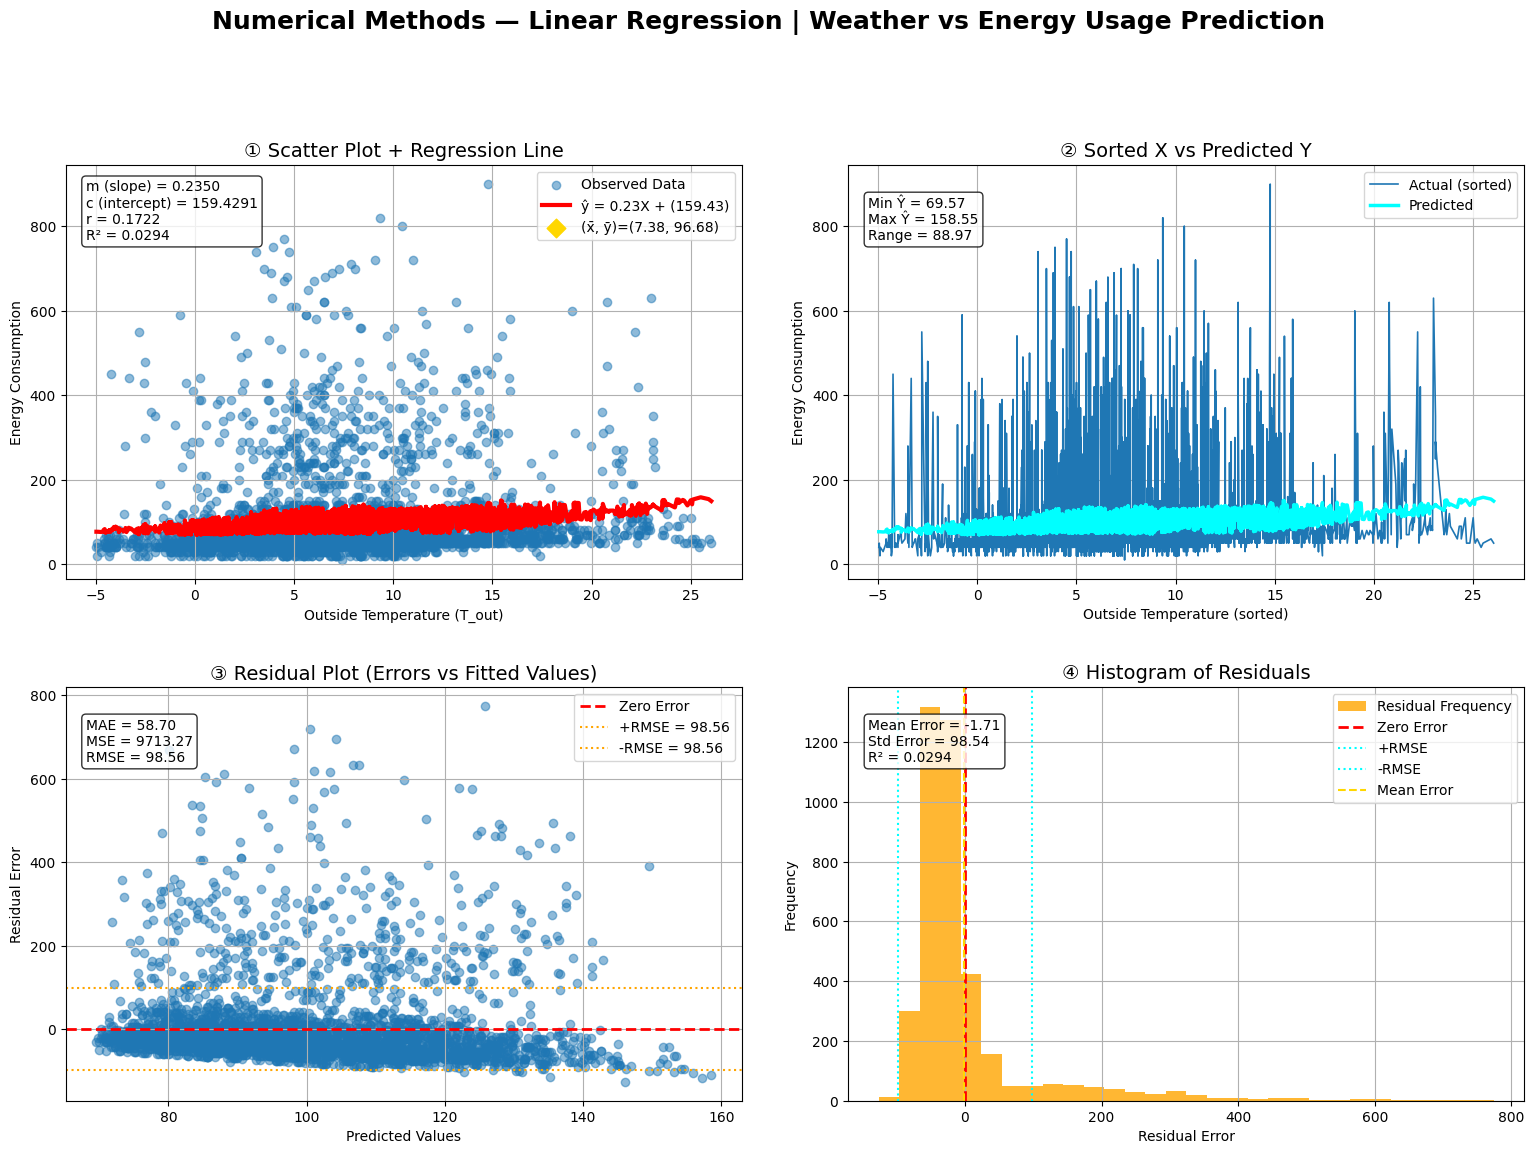

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


# Predictions and Errors
y_pred = model.predict(X_test)
residuals = y_test - y_pred


# Use one feature for graphing (T_out)
x = X_test['T_out'].values
y_actual = y_test.values

# Sort for clean line graphs
sorted_idx = np.argsort(x)
x_sorted = x[sorted_idx]
y_actual_sorted = y_actual[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]


# Metrics

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Regression stats
slope = model.coef_[0]
intercept = model.intercept_
r = np.corrcoef(y_actual, y_pred)[0,1]

# Mean point
x_mean = np.mean(x)
y_mean = np.mean(y_actual)


# Create Dashboard

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "Numerical Methods — Linear Regression | Weather vs Energy Usage Prediction",
    fontsize=18,
    fontweight="bold",
    y=0.98
)


# 1. Scatter Plot + Regression Line

axs[0,0].scatter(
    x, y_actual,
    alpha=0.5,
    label="Observed Data"
)

axs[0,0].plot(
    x_sorted,
    y_pred_sorted,
    color="red",
    linewidth=3,
    label=f"ŷ = {slope:.2f}X + ({intercept:.2f})"
)

axs[0,0].scatter(
    x_mean, y_mean,
    marker="D",
    s=90,
    color="gold",
    label=f"(x̄, ȳ)=({x_mean:.2f}, {y_mean:.2f})"
)

axs[0,0].set_title("① Scatter Plot + Regression Line", fontsize=14)
axs[0,0].set_xlabel("Outside Temperature (T_out)")
axs[0,0].set_ylabel("Energy Consumption")

stats1 = (
    f"m (slope) = {slope:.4f}\n"
    f"c (intercept) = {intercept:.4f}\n"
    f"r = {r:.4f}\n"
    f"R² = {r2:.4f}"
)

axs[0,0].text(
    0.03, 0.82,
    stats1,
    transform=axs[0,0].transAxes,
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

axs[0,0].legend()
axs[0,0].grid(True)


# 2. Saturation Curve / Sorted Actual vs Predicted

axs[0,1].plot(
    x_sorted,
    y_actual_sorted,
    linewidth=1.2,
    label="Actual (sorted)"
)

axs[0,1].plot(
    x_sorted,
    y_pred_sorted,
    linewidth=2.5,
    color="cyan",
    label="Predicted"
)

axs[0,1].set_title("② Sorted X vs Predicted Y", fontsize=14)
axs[0,1].set_xlabel("Outside Temperature (sorted)")
axs[0,1].set_ylabel("Energy Consumption")

stats2 = (
    f"Min Ŷ = {np.min(y_pred):.2f}\n"
    f"Max Ŷ = {np.max(y_pred):.2f}\n"
    f"Range = {(np.max(y_pred)-np.min(y_pred)):.2f}"
)

axs[0,1].text(
    0.03, 0.82,
    stats2,
    transform=axs[0,1].transAxes,
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

axs[0,1].legend()
axs[0,1].grid(True)


# 3. Residual Plot

axs[1,0].scatter(
    y_pred,
    residuals,
    alpha=0.5
)

axs[1,0].axhline(0, color="red", linestyle="--", linewidth=2, label="Zero Error")
axs[1,0].axhline(rmse, color="orange", linestyle=":", label=f"+RMSE = {rmse:.2f}")
axs[1,0].axhline(-rmse, color="orange", linestyle=":", label=f"-RMSE = {rmse:.2f}")

axs[1,0].set_title("③ Residual Plot (Errors vs Fitted Values)", fontsize=14)
axs[1,0].set_xlabel("Predicted Values")
axs[1,0].set_ylabel("Residual Error")

stats3 = (
    f"MAE = {mae:.2f}\n"
    f"MSE = {mse:.2f}\n"
    f"RMSE = {rmse:.2f}"
)

axs[1,0].text(
    0.03, 0.82,
    stats3,
    transform=axs[1,0].transAxes,
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

axs[1,0].legend()
axs[1,0].grid(True)


# 4. Histogram of Residuals

axs[1,1].hist(
    residuals,
    bins=30,
    alpha=0.8,
    color="orange",
    label="Residual Frequency"
)

axs[1,1].axvline(0, color="red", linestyle="--", linewidth=2, label="Zero Error")
axs[1,1].axvline(rmse, color="cyan", linestyle=":", label=f"+RMSE")
axs[1,1].axvline(-rmse, color="cyan", linestyle=":", label=f"-RMSE")
axs[1,1].axvline(np.mean(residuals), color="gold", linestyle="--", label="Mean Error")

axs[1,1].set_title("④ Histogram of Residuals", fontsize=14)
axs[1,1].set_xlabel("Residual Error")
axs[1,1].set_ylabel("Frequency")

stats4 = (
    f"Mean Error = {np.mean(residuals):.2f}\n"
    f"Std Error = {np.std(residuals):.2f}\n"
    f"R² = {r2:.4f}"
)

axs[1,1].text(
    0.03, 0.82,
    stats4,
    transform=axs[1,1].transAxes,
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

axs[1,1].legend()
axs[1,1].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96], pad=3.0)
plt.show()

